# Verification: TCR signaling bistability (Lipniacki et al., 2008)

This notebook verifies the curated population model at three levels:

1. **Reproducibility:** run the BNGL file afresh with BioNetGen 2.9.3 and
   compare its fixed-seed SSA trajectory with the committed reference output.
2. **Model specification:** switch only the action to ODE, then compare every
   observable with a hand-written SciPy implementation of the 37-state
   mass-action system.
3. **Reported simulation:** compare deterministic ppERK with the black curve
   digitized from Fig. 7B of Lipniacki et al. (2008).

The paper adds 30 agonist pMHC molecules at paper time 600 s. The curated model
starts at ligand addition, so reported times are shifted by -600 s. The steep
onset is obscured by colored stochastic curves in the published panel; the
digitized comparison therefore begins 240 s after stimulation.

The supplied formal BNGL uses lumped `u/p/pp` MEK and ERK states with unit
transition propensities and direct `pp -> u` dephosphorylation. The independent
right-hand side below follows that supplied chemical specification rather than
parsing the generated `.net` file. This convention is retained because it is
the B13 source of record and quantitatively reproduces the published Fig. 7B
deterministic trajectory.

**Plot convention:** solid lines are BioNetGen; open markers are the independent
SciPy solution; the thin red line is one fixed-seed exact SSA trajectory.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

MODEL_STEM = "tcr_signaling_bistability_lipniacki2008"


def find_model_dir():
    candidates = [Path.cwd(), Path.cwd() / "models" / MODEL_STEM]
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidates.append(parent / "models" / MODEL_STEM)
    for candidate in candidates:
        if (candidate / f"{MODEL_STEM}.bngl").exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Cannot locate {MODEL_STEM}.bngl")


def find_bng2():
    if os.environ.get("BNG2_PL"):
        return Path(os.environ["BNG2_PL"]).resolve()
    local = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local.exists():
        return local
    found = shutil.which("BNG2.pl")
    if found:
        return Path(found).resolve()
    raise FileNotFoundError("BioNetGen not found; set BNG2_PL")


def load_gdat(path):
    header = Path(path).read_text().splitlines()[0].lstrip("#").split()
    values = np.loadtxt(path, comments="#")
    return pd.DataFrame(values, columns=header)


MODEL_DIR = find_model_dir()
MODEL_FILE = MODEL_DIR / f"{MODEL_STEM}.bngl"
REFERENCE = MODEL_DIR / "reference"
BNG2 = find_bng2()
print(f"Model directory: {MODEL_DIR}")
print(f"BioNetGen: {BNG2}")

Model directory: /Users/l119605/Code/BNGL-Models/models/tcr_signaling_bistability_lipniacki2008
BioNetGen: /Users/l119605/Simulations/BioNetGen-2.9.3/BNG2.pl


## Fresh BioNetGen runs

The first run executes the file exactly as distributed: fixed-seed direct SSA
for three hours. For deterministic verification, a temporary copy changes only
the active action from `ssa` to `ode`; the model body, seed state, rules, and
observables are unchanged.

In [2]:
model_text = MODEL_FILE.read_text()
ssa_action = '''simulate({method=>"ssa",suffix=>"ssa",t_start=>0,t_end=>10800,n_steps=>600,\\
    seed=>200807,print_functions=>1})'''
ode_action = '''simulate({method=>"ode",suffix=>"ode",t_start=>0,t_end=>10800,n_steps=>600,\\
    print_functions=>1,rtol=>1e-10,atol=>1e-10})'''
assert model_text.count(ssa_action) == 1

with tempfile.TemporaryDirectory(prefix="lipniacki2008_") as temp_name:
    temp_dir = Path(temp_name)

    fresh_model = temp_dir / MODEL_FILE.name
    shutil.copy2(MODEL_FILE, fresh_model)
    ssa_run = subprocess.run(
        ["perl", str(BNG2), fresh_model.name],
        cwd=temp_dir,
        check=True,
        capture_output=True,
        text=True,
    )
    fresh_ssa = load_gdat(temp_dir / f"{MODEL_STEM}_ssa.gdat")
    generated_net = (temp_dir / f"{MODEL_STEM}.net").read_text()

    ode_stem = f"{MODEL_STEM}_odecheck"
    ode_model = temp_dir / f"{ode_stem}.bngl"
    ode_model.write_text(model_text.replace(ssa_action, ode_action))
    ode_run = subprocess.run(
        ["perl", str(BNG2), ode_model.name],
        cwd=temp_dir,
        check=True,
        capture_output=True,
        text=True,
    )
    fresh_ode = load_gdat(temp_dir / f"{ode_stem}_ode.gdat")

reference_ssa = load_gdat(REFERENCE / f"{MODEL_STEM}_ssa.gdat")
reference_ode = load_gdat(REFERENCE / f"{MODEL_STEM}_ode.gdat")

ssa_reference_error = np.max(
    np.abs(fresh_ssa.to_numpy() - reference_ssa.to_numpy())
)
ode_reference_error = np.max(
    np.abs(fresh_ode.to_numpy() - reference_ode.to_numpy())
)

species_count = generated_net.count("\n    ")  # replaced below by block parsing
species_block = generated_net.split("begin species", 1)[1].split("end species", 1)[0]
reaction_block = generated_net.split("begin reactions", 1)[1].split(
    "end reactions", 1
)[0]
species_count = sum(bool(line.strip()) for line in species_block.splitlines())
reaction_count = sum(bool(line.strip()) for line in reaction_block.splitlines())

print(f"Network: {species_count} species, {reaction_count} reactions")
print(f"Fresh SSA vs committed reference max abs error: {ssa_reference_error:.2e}")
print(f"Fresh ODE vs committed reference max abs error: {ode_reference_error:.2e}")

Network: 37 species, 97 reactions
Fresh SSA vs committed reference max abs error: 0.00e+00
Fresh ODE vs committed reference max abs error: 0.00e+00


## Independent 37-state mass-action equations

States `y1`-`y37` follow Appendix A: agonist receptor complexes (`y1`-`y10`),
antagonist receptor complexes (`y11`-`y20`), free/bound TCR-SHP1-LCK
populations (`y21`-`y29`), and ZAP70-MEK-ERK states (`y30`-`y37`). The
implementation is explicit and does not inspect BioNetGen's generated reaction
or stoichiometry blocks.

In [3]:
p = {
    "b1": 0.3 / 30000,
    "b2": 0.3 / 30000,
    "d1": 0.05,
    "d2": 1.0,
    "lb": 0.3 / 100000,
    "ly1": 5.0 / 300000,
    "ly2": 0.3,
    "ls1": 0.1,
    "ls2": 0.5 / 300000,
    "tp": 0.05,
    "s0": 1e-5,
    "s1": 30.0 / 300000,
    "s2": 0.0006,
    "s3": 0.05,
    "z0": 2e-6,
    "z1": 5.0 / 100000,
    "z2": 0.02,
    "m1": 5.0 / 100000,
    "m2": 0.02,
    "e1": 5.0 / 300000,
    "e2": 0.02,
}


def rhs(_time, y):
    (
        y1, y2, y3, y4, y5, y6, y7, y8, y9, y10,
        y11, y12, y13, y14, y15, y16, y17, y18, y19, y20,
        y21, y22, y23, y24, y25, y26, y27, y28, y29, y30,
        y31, y32, y33, y34, y35, y36, y37,
    ) = y
    q = p
    dy = np.zeros(37)

    dy[0] = q["d1"] * sum((y2, y3, y4, y5, y6, y7, y8, y9, y10, y23, y24))
    dy[0] -= q["b1"] * y1 * y21
    dy[1] = q["b1"] * y1 * y21 + (q["s2"] + q["s3"]) * y23
    dy[1] -= (q["d1"] + q["lb"] * y27 + q["ly1"] * y29) * y2
    dy[2] = q["lb"] * y27 * y2 + q["ls1"] * y4
    dy[2] += (q["s2"] + q["s3"]) * y24
    dy[2] -= (q["d1"] + q["ly2"] + q["ls2"] * y37 + q["ly1"] * y29) * y3
    dy[3] = q["ls2"] * y37 * y3 - (q["d1"] + q["ly2"] + q["ls1"]) * y4
    dy[4] = q["ly2"] * y3 + q["ls1"] * y6
    dy[4] -= (q["d1"] + q["tp"] + q["ls2"] * y37 + q["ly1"] * y29) * y5
    dy[5] = q["ly2"] * y4 + q["ls2"] * y37 * y5
    dy[5] -= (q["d1"] + q["tp"] + q["ls1"]) * y6
    dy[6] = q["tp"] * y5 + q["ls1"] * y8
    dy[6] -= (q["d1"] + q["tp"] + q["ls2"] * y37 + q["ly1"] * y29) * y7
    dy[7] = q["tp"] * y6 + q["ls2"] * y37 * y7
    dy[7] -= (q["d1"] + q["tp"] + q["ls1"]) * y8
    dy[8] = q["tp"] * y7 + q["ls1"] * y10
    dy[8] -= (q["d1"] + q["ls2"] * y37 + q["ly1"] * y29) * y9
    dy[9] = q["tp"] * y8 + q["ls2"] * y37 * y9
    dy[9] -= (q["d1"] + q["ls1"]) * y10

    dy[10] = q["d2"] * sum(
        (y12, y13, y14, y15, y16, y17, y18, y19, y20, y25, y26)
    )
    dy[10] -= q["b2"] * y11 * y21
    dy[11] = q["b2"] * y11 * y21 + (q["s2"] + q["s3"]) * y25
    dy[11] -= (q["d2"] + q["lb"] * y27 + q["ly1"] * y29) * y12
    dy[12] = q["lb"] * y27 * y12 + q["ls1"] * y14
    dy[12] += (q["s2"] + q["s3"]) * y26
    dy[12] -= (q["d2"] + q["ly2"] + q["ls2"] * y37 + q["ly1"] * y29) * y13
    dy[13] = q["ls2"] * y37 * y13 - (q["d2"] + q["ly2"] + q["ls1"]) * y14
    dy[14] = q["ly2"] * y13 + q["ls1"] * y16
    dy[14] -= (q["d2"] + q["tp"] + q["ls2"] * y37 + q["ly1"] * y29) * y15
    dy[15] = q["ly2"] * y14 + q["ls2"] * y37 * y15
    dy[15] -= (q["d2"] + q["tp"] + q["ls1"]) * y16
    dy[16] = q["tp"] * y15 + q["ls1"] * y18
    dy[16] -= (q["d2"] + q["tp"] + q["ls2"] * y37 + q["ly1"] * y29) * y17
    dy[17] = q["tp"] * y16 + q["ls2"] * y37 * y17
    dy[17] -= (q["d2"] + q["tp"] + q["ls1"]) * y18
    dy[18] = q["tp"] * y17 + q["ls1"] * y20
    dy[18] -= (q["d2"] + q["ls2"] * y37 + q["ly1"] * y29) * y19
    dy[19] = q["tp"] * y18 + q["ls2"] * y37 * y19
    dy[19] -= (q["d2"] + q["ls1"]) * y20

    dy[20] = q["d1"] * sum((y2, y3, y4, y5, y6, y7, y8, y9, y10))
    dy[20] += q["d2"] * sum((y12, y13, y14, y15, y16, y17, y18, y19, y20))
    dy[20] += (q["s2"] + q["s3"]) * y22
    dy[20] -= q["b1"] * y1 * y21 + q["b2"] * y11 * y21 + q["ly1"] * y29 * y21
    dy[21] = q["ly1"] * y29 * y21
    dy[21] += q["d1"] * (y23 + y24) + q["d2"] * (y25 + y26)
    dy[21] -= (q["s2"] + q["s3"]) * y22
    dy[22] = q["ly1"] * y29 * y2 - (q["s2"] + q["s3"] + q["d1"]) * y23
    dy[23] = q["ly1"] * y29 * (y3 + y5 + y7 + y9)
    dy[23] -= (q["s2"] + q["s3"] + q["d1"]) * y24
    dy[24] = q["ly1"] * y29 * y12 - (q["s2"] + q["s3"] + q["d2"]) * y25
    dy[25] = q["ly1"] * y29 * (y13 + y15 + y17 + y19)
    dy[25] -= (q["s2"] + q["s3"] + q["d2"]) * y26
    dy[26] = q["d1"] * sum((y3, y4, y5, y6, y7, y8, y9, y10, y24))
    dy[26] += q["d2"] * sum((y13, y14, y15, y16, y17, y18, y19, y20, y26))
    dy[26] -= q["lb"] * (y2 + y12) * y27
    active_lck_1 = y5 + y7 + y9
    active_lck_2 = y15 + y17 + y19
    bound_shp = y22 + y23 + y24 + y25 + y26
    dy[27] = q["s2"] * (y29 + bound_shp)
    dy[27] -= q["s1"] * (active_lck_1 + active_lck_2) * y28 + q["s0"] * y28
    recruitable_tcr = y2 + y3 + y5 + y7 + y9 + y12 + y13 + y15 + y17 + y19 + y21
    dy[28] = q["s1"] * (active_lck_1 + active_lck_2) * y28
    dy[28] += q["s3"] * bound_shp + q["s0"] * y28
    dy[28] -= q["s2"] * y29 + q["ly1"] * recruitable_tcr * y29

    active_tcr = y9 + y10 + y19 + y20
    dy[29] = q["z2"] * y31 - q["z1"] * active_tcr * y30 - q["z0"] * y30
    dy[30] = q["z1"] * active_tcr * y30 + q["z0"] * y30 - q["z2"] * y31
    dy[31] = q["m2"] * (y33 + y34) - q["m1"] * y31 * y32
    dy[32] = q["m1"] * y31 * (y32 - y33) - q["m2"] * y33
    dy[33] = q["m1"] * y31 * y33 - q["m2"] * y34
    dy[34] = q["e2"] * (y36 + y37) - q["e1"] * y34 * y35
    dy[35] = q["e1"] * y34 * (y35 - y36) - q["e2"] * y36
    dy[36] = q["e1"] * y34 * y36 - q["e2"] * y37
    return dy


y0 = np.zeros(37)
y0[[0, 20, 21, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]] = [
    30, 25603, 4397, 100000, 295082, 521, 99990, 10,
    97561, 2379, 60, 285833, 13498, 669,
]

t_eval = fresh_ode["time"].to_numpy()
solution = solve_ivp(
    rhs,
    (t_eval[0], t_eval[-1]),
    y0,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-10,
    atol=1e-10,
)
assert solution.success, solution.message
y = solution.y.T

independent = pd.DataFrame(
    {
        "time": t_eval,
        "Obs_Cplx_TCR_Agonist": y[:, 1:10].sum(axis=1) + y[:, 22] + y[:, 23],
        "Obs_Cplx_TCR_Antagonist": y[:, 11:20].sum(axis=1) + y[:, 24] + y[:, 25],
        "Obs_State_LCK_Y_P": y[:, 4:10].sum(axis=1) + y[:, 14:20].sum(axis=1),
        "Obs_State_SHP1_P": y[:, 21:26].sum(axis=1) + y[:, 28],
        "Obs_State_ZAP70_P": y[:, 30],
        "Obs_State_MEK_PP": y[:, 33],
        "Obs_State_ERK_PP": y[:, 36],
        "Frac_ERK_PP": y[:, 36] / 300000,
    }
)

observable_names = [name for name in fresh_ode.columns if name != "time"]
absolute = np.abs(
    fresh_ode[observable_names].to_numpy()
    - independent[observable_names].to_numpy()
)
relative = absolute / np.maximum(
    np.abs(independent[observable_names].to_numpy()), 1.0
)
scales = np.maximum(
    np.max(np.abs(independent[observable_names].to_numpy()), axis=0), 1.0
)
normalized_l2 = np.sqrt(np.mean(absolute**2, axis=0)) / scales

pools = np.column_stack(
    [
        y[:, 0] + y[:, 1:10].sum(axis=1) + y[:, 22] + y[:, 23],
        y[:, 10] + y[:, 11:20].sum(axis=1) + y[:, 24] + y[:, 25],
        y[:, 1:10].sum(axis=1) + y[:, 11:26].sum(axis=1),
        y[:, 2:10].sum(axis=1) + y[:, 12:20].sum(axis=1) + y[:, 23] + y[:, 25] + y[:, 26],
        y[:, 21:26].sum(axis=1) + y[:, 27] + y[:, 28],
        y[:, 29:31].sum(axis=1),
        y[:, 31:34].sum(axis=1),
        y[:, 34:37].sum(axis=1),
    ]
)
pool_names = ["agonist", "antagonist", "TCR", "LCK", "SHP1", "ZAP70", "MEK", "ERK"]
pool_drift = np.max(
    np.abs(pools - pools[0]) / np.maximum(np.abs(pools[0]), 1.0),
    axis=0,
)

print(f"BNG vs independent max relative error: {relative.max():.2e}")
print(f"Largest normalized L2 error: {normalized_l2.max():.2e}")
print(f"Largest molecular-pool conservation error: {pool_drift.max():.2e}")

BNG vs independent max relative error: 4.18e-09
Largest normalized L2 error: 2.31e-10
Largest molecular-pool conservation error: 2.25e-14


## Quantitative comparison with Fig. 7B

The PDF page was rendered at 400 dpi. Panel axes were calibrated to
`0..12000 s` and `0..300000 ppERK molecules`. Neutral dark pixels belonging to
the black deterministic curve were segmented and sampled every 120 s. The
comparison uses:

- normalized RMSE over the digitized decay and plateau, tolerance **1% full scale**;
- peak-amplitude error, tolerance **2% full scale**;
- late plateau error, tolerance **1% full scale**.

These tolerances exceed the 400-dpi line thickness and pixel-calibration
uncertainty while remaining stringent relative to the 300,000-molecule axis.

In [4]:
digitized = pd.read_csv(
    REFERENCE / "lipniacki2008_fig7b_deterministic_ppERK_digitized.csv",
    comment="#",
)
reported_time = digitized["stimulation_time_s"].to_numpy()
reported_ppERK = digitized["ppERK_molecules"].to_numpy()
predicted_ppERK = np.interp(
    reported_time,
    fresh_ode["time"],
    fresh_ode["Obs_State_ERK_PP"],
)
reported_error = predicted_ppERK - reported_ppERK
full_scale = 300000.0
reported_nrmse = np.sqrt(np.mean(reported_error**2)) / full_scale
reported_median_abs = np.median(np.abs(reported_error)) / full_scale
reported_peak_error = (
    abs(fresh_ode["Obs_State_ERK_PP"].max() - reported_ppERK.max()) / full_scale
)
late = reported_time >= 5400
reported_plateau = np.median(reported_ppERK[late])
predicted_plateau = np.median(predicted_ppERK[late])
reported_plateau_error = abs(predicted_plateau - reported_plateau) / full_scale

assert reported_nrmse <= 0.01
assert reported_peak_error <= 0.02
assert reported_plateau_error <= 0.01

print(f"Fig. 7B normalized RMSE: {100 * reported_nrmse:.3f}% FS")
print(f"Fig. 7B median absolute error: {100 * reported_median_abs:.3f}% FS")
print(f"Fig. 7B peak-amplitude error: {100 * reported_peak_error:.3f}% FS")
print(
    "Fig. 7B plateau: "
    f"BNG {predicted_plateau:.0f}; digitized {reported_plateau:.0f}; "
    f"error {100 * reported_plateau_error:.3f}% FS"
)

Fig. 7B normalized RMSE: 0.219% FS
Fig. 7B median absolute error: 0.095% FS
Fig. 7B peak-amplitude error: 1.112% FS
Fig. 7B plateau: BNG 216512; digitized 216797; error 0.095% FS


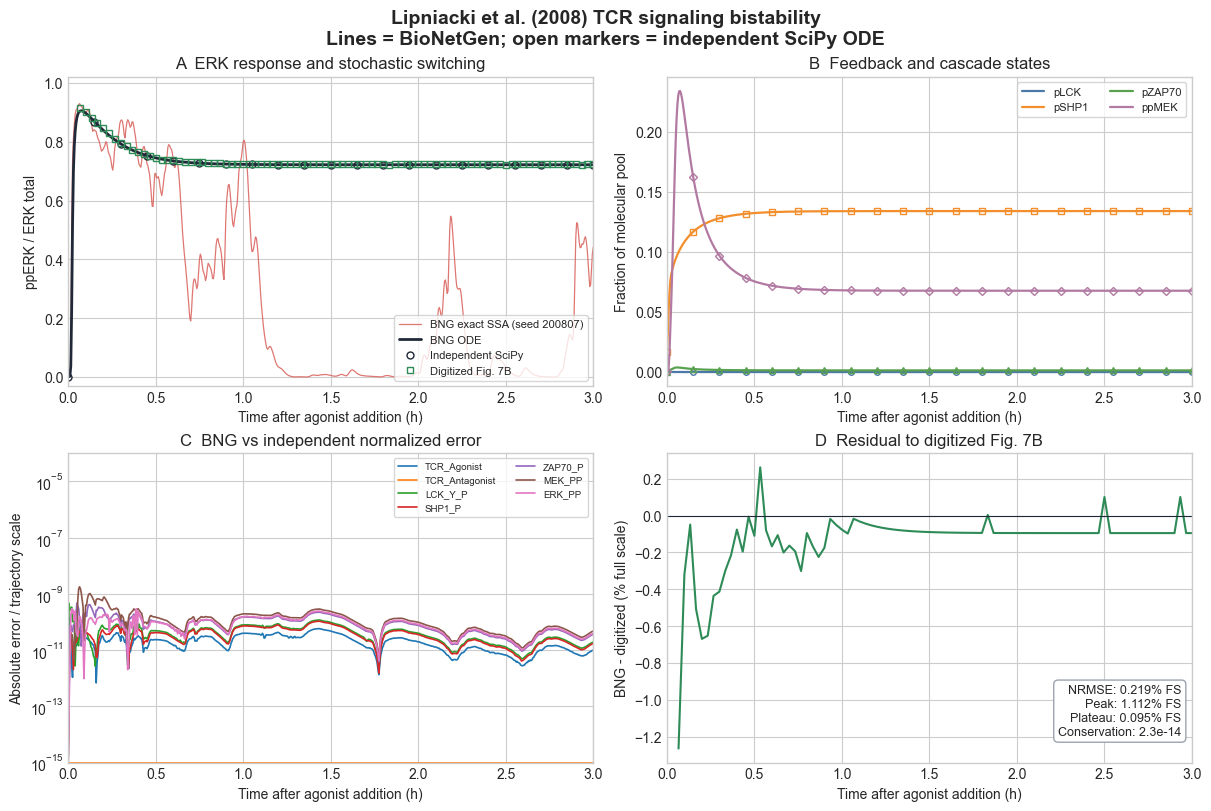

Saved /Users/l119605/Code/BNGL-Models/models/tcr_signaling_bistability_lipniacki2008/verify_lipniacki2008.png


In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
time_h = fresh_ode["time"].to_numpy() / 3600
marker_slice = slice(None, None, 30)

ax = axes[0, 0]
ax.plot(
    fresh_ssa["time"] / 3600,
    fresh_ssa["Obs_State_ERK_PP"] / 300000,
    color="#d95f59",
    lw=0.9,
    alpha=0.85,
    label="BNG exact SSA (seed 200807)",
)
ax.plot(
    time_h,
    fresh_ode["Obs_State_ERK_PP"] / 300000,
    color="#1f2937",
    lw=2.0,
    label="BNG ODE",
)
ax.plot(
    time_h[marker_slice],
    independent["Obs_State_ERK_PP"].to_numpy()[marker_slice] / 300000,
    "o",
    mfc="none",
    mec="#1f2937",
    ms=5,
    label="Independent SciPy",
)
ax.plot(
    reported_time / 3600,
    reported_ppERK / 300000,
    "s",
    mfc="none",
    mec="#2e8b57",
    ms=4,
    label="Digitized Fig. 7B",
)
ax.set(
    title="A  ERK response and stochastic switching",
    xlabel="Time after agonist addition (h)",
    ylabel="ppERK / ERK total",
    xlim=(0, 3),
    ylim=(-0.03, 1.02),
)
ax.legend(frameon=True, fontsize=8, loc="lower right")

ax = axes[0, 1]
traces = [
    ("Obs_State_LCK_Y_P", 100000, "#4c78a8", "pLCK"),
    ("Obs_State_SHP1_P", 300000, "#f28e2b", "pSHP1"),
    ("Obs_State_ZAP70_P", 100000, "#59a14f", "pZAP70"),
    ("Obs_State_MEK_PP", 100000, "#b279a2", "ppMEK"),
]
markers = ["o", "s", "^", "D"]
for (name, total, color, label), marker in zip(traces, markers):
    ax.plot(time_h, fresh_ode[name] / total, color=color, lw=1.6, label=label)
    ax.plot(
        time_h[marker_slice],
        independent[name].to_numpy()[marker_slice] / total,
        marker,
        mfc="none",
        mec=color,
        ms=4,
        ls="none",
    )
ax.set(
    title="B  Feedback and cascade states",
    xlabel="Time after agonist addition (h)",
    ylabel="Fraction of molecular pool",
    xlim=(0, 3),
)
ax.legend(frameon=True, fontsize=8, ncol=2)

ax = axes[1, 0]
for idx, name in enumerate(observable_names):
    if name == "Frac_ERK_PP":
        continue
    scale = scales[idx]
    ax.semilogy(
        time_h,
        np.maximum(absolute[:, idx] / scale, 1e-15),
        lw=1.2,
        label=name.replace("Obs_State_", "").replace("Obs_Cplx_", ""),
    )
ax.set(
    title="C  BNG vs independent normalized error",
    xlabel="Time after agonist addition (h)",
    ylabel="Absolute error / trajectory scale",
    xlim=(0, 3),
    ylim=(1e-15, 1e-4),
)
ax.legend(frameon=True, fontsize=7, ncol=2)

ax = axes[1, 1]
ax.plot(
    reported_time / 3600,
    100 * reported_error / full_scale,
    color="#2e8b57",
    lw=1.5,
)
ax.axhline(0, color="#1f2937", lw=0.8)
ax.set(
    title="D  Residual to digitized Fig. 7B",
    xlabel="Time after agonist addition (h)",
    ylabel="BNG - digitized (% full scale)",
    xlim=(0, 3),
)
summary = (
    f"NRMSE: {100 * reported_nrmse:.3f}% FS\n"
    f"Peak: {100 * reported_peak_error:.3f}% FS\n"
    f"Plateau: {100 * reported_plateau_error:.3f}% FS\n"
    f"Conservation: {pool_drift.max():.1e}"
)
ax.text(
    0.98,
    0.08,
    summary,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox={"boxstyle": "round,pad=0.35", "fc": "white", "ec": "#9ca3af"},
)

fig.suptitle(
    "Lipniacki et al. (2008) TCR signaling bistability\n"
    "Lines = BioNetGen; open markers = independent SciPy ODE",
    fontsize=14,
    fontweight="bold",
)
figure_path = MODEL_DIR / "verify_lipniacki2008.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {figure_path}")